In [9]:
import requests
import pandas as pd

url = 'https://api.auto.dev/listings'
headers = {'Authorization': 'Bearer API_KEY'}

# get one page of listings
def get_cars_onepage(make, model, page = 1, show_info = False):
    #make = brand
    #filtering
    params = {
        'vehicle.make': make,
        'vehicle.model': model,
        'zip': '92122',
        'distance': 200,
        'limit': 20,
        'page': page,
        'retailListing.cpo': 'true',
        'includes': 'total'
    }

    response = requests.get(
        url,
        headers = headers,
        params = params
    )

    response.raise_for_status()

    data = response.json()

    if show_info:
        print('total matching cars:', data.get('total'))
        print('result on this page:', len(data['data']))
    
    #start washing
    cars = []

    for car in data['data']:
        vehicle = car['vehicle']
        listing = car['retailListing']

        cars.append({
            'vin': car.get('vin'),
            'year': vehicle.get('year'),
            'make': vehicle.get('make'),
            'model': vehicle.get('model'),
            'trim': vehicle.get('trim'),
            'price': listing.get('price'),
            'miles': listing.get('miles'),
            'cpo': listing.get('cpo'),
            'dealer': listing.get('dealer'),
            'city': listing.get('city'),
            'state': listing.get('state'),
            'zip': listing.get('zip'),
            'listing_url': listing.get('vdp')
        })

    return pd.DataFrame(cars)

#get all available pages, up to 20 pages
def get_cars_allpages(make, model):
    pages = []
    #determine page numbers
    for page in range(1, 21):
        current_page = get_cars_onepage(
            make,
            model,
            page = page,
            show_info = (page == 1)
        )

        pages.append(current_page)

        if len(current_page) < 20:
            break

    return pd.concat(pages, ignore_index = True)

In [10]:
#API Data Collection
#⚠️DO NOT RERUN!!!!!!!
#⚠️ONLY RUN ONCE!!!!!!!
#data should be saved to CSV

bmw = get_cars_allpages('BMW', 'X3')
audi = get_cars_allpages('Audi', 'Q5')
benz = get_cars_allpages('Mercedes-Benz', 'GLC 300')

all_cars = pd.concat(
    [bmw, audi, benz],
    ignore_index = True
)

all_cars.to_csv('all_cars.csv', index = False)

total matching cars: 95
result on this page: 20
total matching cars: 29
result on this page: 20
total matching cars: 24
result on this page: 20


In [4]:
import pandas as pd
all_cars = pd.read_csv('all_cars.csv')

print(all_cars.shape)
display(all_cars.head())
all_cars.info()
print(all_cars.isna().sum())

(148, 13)


,vin,year,make,model,trim,price,miles,cpo,dealer,city,state,zip,listing_url
0,5UX43DP06R9X47664,2024,BMW,X3,sDrive30i,43793,6867,True,Pacific BMW,Glendale,CA,NaN,https://www.autolist.com/bmw-x3#vin=5UX43DP06R...
1,5UX53GP04S9080959,2025,BMW,X3,30 xDrive,44101,10746,True,BMW of Chula Vista,Chula Vista,CA,NaN,https://www.autolist.com/bmw-x3#vin=5UX53GP04S...
2,5UX53GP07T9204725,2026,BMW,X3,30 xDrive,43885,7618,True,BMW of San Diego,San Diego,CA,NaN,https://www.autolist.com/bmw-x3#vin=5UX53GP07T...
3,5UX43DP04P9S09509,2023,BMW,X3,sDrive30i,32893,29591,True,Pacific BMW,Glendale,CA,NaN,https://www.autolist.com/bmw-x3#vin=5UX43DP04P...
4,5UX43DP07R9V46257,2024,BMW,X3,sDrive30i,33651,32876,True,BMW of Downtown Los Angeles,Los Angeles,CA,NaN,https://www.autolist.com/bmw-x3#vin=5UX43DP07R...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          148 non-null    object 
 1   year         148 non-null    int64  
 2   make         148 non-null    object 
 3   model        148 non-null    object 
 4   trim         148 non-null    object 
 5   price        148 non-null    int64  
 6   miles        148 non-null    int64  
 7   cpo          148 non-null    bool   
 8   dealer       148 non-null    object 
 9   city         148 non-null    object 
 10  state        148 non-null    object 
 11  zip          129 non-null    float64
 12  listing_url  148 non-null    object 
dtypes: bool(1), float64(1), int64(3), object(8)
memory usage: 14.1+ KB
vin             0
year            0
make            0
model           0
trim            0
price           0
miles           0
cpo             0
dealer          0
city            0
state        

In [5]:
all_cars.duplicated().sum()

0

In [6]:
all_cars[['year', 'price', 'miles']].describe()

,year,price,miles
count,148.000000,148.000000,148.000000
mean,2024.486486,41104.459459,18364.479730
std,1.290923,10618.438863,15802.661572
min,2021.000000,85.000000,523.000000
25%,2023.000000,34791.000000,6157.250000
50%,2025.000000,40379.500000,10681.500000
75%,2026.000000,48121.250000,29596.750000
max,2026.000000,62685.000000,78157.000000


In [7]:
all_cars[all_cars['price'] < 10000]

,vin,year,make,model,trim,price,miles,cpo,dealer,city,state,zip,listing_url
139,W1NKM4GB1TF517250,2026,Mercedes-Benz,GLC 300,GLC 300,85,5556,True,mercedes benz of west covina,West Covina,CA,91791.0,https://mbwestcovina.com/certified/Mercedes-Be...
140,W1NKM4GB5TF498654,2026,Mercedes-Benz,GLC 300,GLC 300,85,5247,True,mercedes benz of west covina,West Covina,CA,91791.0,https://mbwestcovina.com/certified/Mercedes-Be...
141,W1NKM4GB8TF488376,2026,Mercedes-Benz,GLC 300,GLC 300,85,6834,True,mercedes benz of west covina,West Covina,CA,91791.0,https://mbwestcovina.com/certified/Mercedes-Be...


In [8]:
all_cars = all_cars[all_cars['price'] >= 10000].copy()
all_cars.reset_index(drop = True, inplace = True)
print(all_cars.shape)
all_cars[['year', 'price', 'miles']].describe()

(145, 13)


,year,price,miles
count,145.000000,145.000000,145.000000
mean,2024.455172,41953.137931,18622.800000
std,1.285492,8906.227414,15861.967841
min,2021.000000,19162.000000,523.000000
25%,2023.000000,34898.000000,6194.000000
50%,2025.000000,40897.000000,11273.000000
75%,2026.000000,48488.000000,29614.000000
max,2026.000000,62685.000000,78157.000000


In [9]:
all_cars['zip'] = all_cars['zip'].astype('Int64')
print(all_cars['zip'].dtype)
print(all_cars['zip'].isna().sum())

all_cars[['city', 'state', 'zip']].head(10)

Int64
19


,city,state,zip
0,Glendale,CA,<NA>
1,Chula Vista,CA,<NA>
2,San Diego,CA,<NA>
3,Glendale,CA,<NA>
4,Los Angeles,CA,<NA>
5,Montebello,CA,<NA>
6,Buena Park,CA,90621
7,Buena Park,CA,90621
8,Buena Park,CA,90621
9,Buena Park,CA,90621


In [10]:
all_cars.groupby(['make', 'model', 'trim']).size().sort_values(ascending = False)

make           model    trim                                          
BMW            X3       sDrive30i                                         39
                        30 xDrive                                         32
Audi           Q5       Premium Plus                                      15
Mercedes-Benz  GLC 300  4MATIC                                            13
BMW            X3       xDrive30i                                         11
Audi           Q5       Premium                                            9
Mercedes-Benz  GLC 300  GLC 300                                            8
BMW            X3       M40i                                               6
Audi           Q5       Premium Plus S line                                3
BMW            X3       M50 xDrive                                         2
                        sDrive30i Sports Activity Vehicle                  2
Audi           Q5       45 Premium                                         1
     

In [11]:
#let's create a new file for the clean data!
all_cars.to_csv('all_cars_clean.csv', index = False)

In [27]:
# ===== PRESENTATION: RESTART HERE =====

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols

all_cars = pd.read_csv("all_cars_clean.csv")

print('clean dataset loaded:', all_cars.shape)

clean dataset loaded: (145, 13)


In [28]:
model_summary = all_cars.groupby('model').agg(
    count = ('price', 'count'),
    avg_price=('price', 'mean'),
    avg_miles=('miles', 'mean')
)

model_summary

,count,avg_price,avg_miles
model,,,
GLC 300,21,48822.476190,15194.619048
Q5,29,40984.965517,10966.379310
X3,95,40730.200000,21717.831579


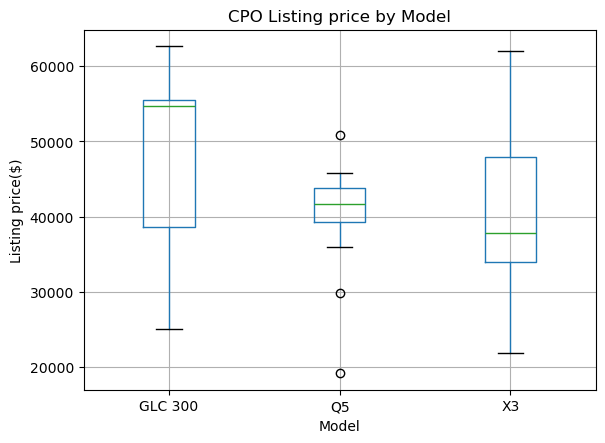

In [29]:
#The boxplot lets us compare both the typical price and the price distribution across the three models.
import matplotlib.pyplot as plt

all_cars.boxplot(
    column = 'price',
    by = 'model'
)

plt.title('CPO Listing price by Model')
plt.suptitle('')
plt.xlabel('Model')
plt.ylabel('Listing price($)')
plt.show()

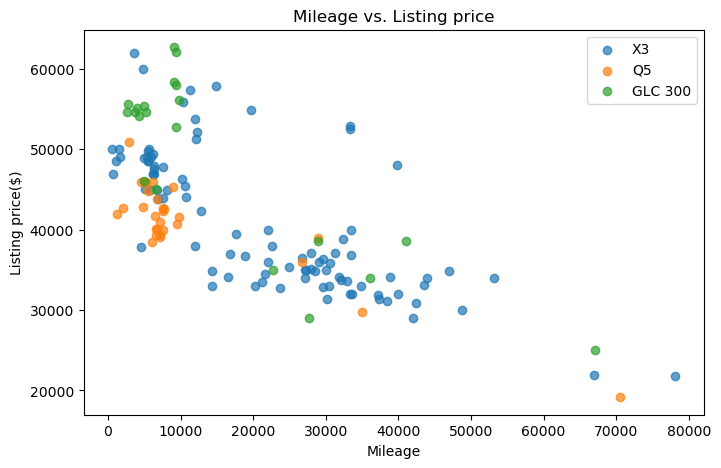

In [30]:
#using scatterplot to examine the relationship between mileage and listing price

plt.figure(figsize = (8, 5))

for model in all_cars['model'].unique():
    subset = all_cars[all_cars['model'] == model]

    plt.scatter(
        subset['miles'],
        subset['price'],
        label = model,
        alpha = 0.7
    )

plt.xlabel('Mileage')
plt.ylabel('Listing price($)')
plt.title('Mileage vs. Listing price')
plt.legend()
plt.show()

In [31]:
year_summary = all_cars.groupby('year').agg(
    count = ('price', 'count'),
    avg_price = ('price', 'mean')
)

year_summary

,count,avg_price
year,,
2021,3,22014.666667
2022,2,31499.000000
2023,36,34272.250000
2024,30,39594.833333
2025,33,44027.272727
2026,41,50722.365854


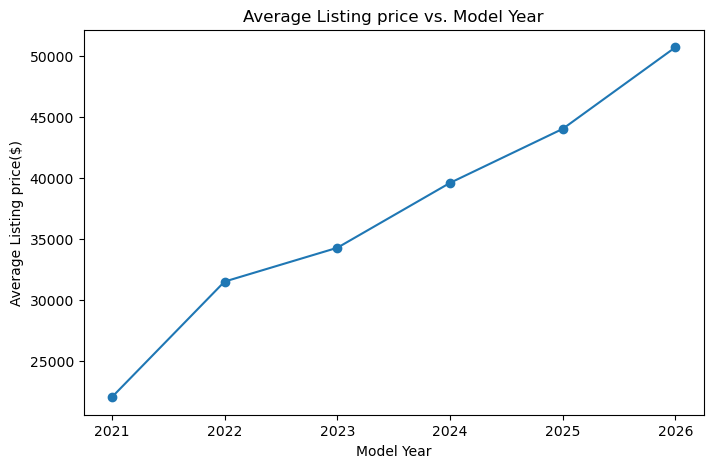

In [32]:
year_summary['avg_price'].plot(
    kind = 'line',
    marker = 'o',
    figsize = (8, 5)
)

plt.xlabel('Model Year')
plt.ylabel('Average Listing price($)')
plt.title('Average Listing price vs. Model Year')
plt.show()

In [33]:
from statsmodels.formula.api import ols

price_model = ols(
    'price ~ miles + year + C(model)',
    data=all_cars
).fit()

price_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.701
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     81.98
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           1.04e-35
Time:                        09:35:33   Log-Likelihood:                -1436.5
No. Observations:                 145   AIC:                             2883.
Df Residuals:                     140   BIC:                             2898.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -6.444e+06   1.13e+06     -5.720      0.000   -8.67e+06   -4.22e+06
C(model)[T.Q5] -7998.8639   1448.367     -5.523      0.000   -1.09e+04   -5135.364
C(model)[T.X3] -4502.6318   1212.673     -3.713      0.000   -6900.152   -2105.112
miles             -0.2113      0.046     -4.606      0.000      -0.302      -0.121
year            3208.0592    556.122      5.769      0.000    2108.576    4307.543
==============================================================================
Omnibus:                       52.835   Durbin-Watson:                   1.909
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              114.466
Skew:                           1.597   Prob(JB):                     1.39e-25
Kurtosis:                       5.957   Cond. No.                     6.72e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.72e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

train, test = train_test_split(
    all_cars,
    test_size=0.2,
    random_state=42
)

test_model = ols(
    "price ~ miles + year + C(model)",
    data=train
).fit()

test["predicted_price"] = test_model.predict(test)

mae = mean_absolute_error(
    test["price"],
    test["predicted_price"]
)

test_r2 = r2_score(
    test["price"],
    test["predicted_price"]
)

print("Test MAE:", round(mae, 2))
print("Test R-squared:", round(test_r2, 3))

Test MAE: 2881.01
Test R-squared: 0.811


In [2]:
#Welcome to Finder cell^ ^Let's input some necessary info before we get the matching car!
def car_finder():
    brand = input("Welcome. What's the brand you are looking for?").strip().lower()

    if brand == 'bmw':
        model = 'X3'
    elif brand == 'audi':
        model = 'Q5'
    elif brand in ['mercedes-benz', 'mercedes', 'benz']:
        model = 'GLC 300'
    else:
        print('Sorry, this project is currently designed to support searching for the BMW, Audi, and Mercedes-Benz.')
        return
        
    #users can enter these data to find the cars match their requirements the most
    max_price = int(input("What's your maximum budget?"))
    max_miles = int(input("What's your expectation for the maximum mileage?"))
    min_year = int(input("What's the expectation for the minimum model year?"))
    #users also can choose how to arrange the results(by price, or by mileage)
    sort_by = input(
        "How would you like to sort the results? (price / mileage):"
    ).strip().lower()

    results = all_cars[
        (all_cars['model'] == model) &
        (all_cars['price'] <= max_price) &
        (all_cars['miles'] <= max_miles) &
        (all_cars['year'] >= min_year)
    ].copy()

    results = results[[
            'year',
            'make',
            'model',
            'trim',
            'price',
            'miles',
            'dealer',
            'city',
            'vin',
            'listing_url'
        ]]

    if sort_by == "mileage":
        results = results.sort_values('miles')
    else:
        results = results.sort_values('price')

    if len(results) == 0:
        print('\nSorry, no matching cars were found.')
        return

    print(f"\nFound {len(results)} matching cars:")
    return results

In [ ]:
#final output finder
car_finder()